In [1]:
import SimpleITK as sitk
import numpy as np
import pyvista as pv
from morphometry.cartilage import knee

In [2]:
image = sitk.ReadImage('/home/simon/Data/Duesseldorf/T1rho/P04/1Relaxed/1Relaxed.nii.gz')

In [3]:
import nibabel as nib

image_2 = nib.load('/home/simon/Data/Duesseldorf/T1rho/P04/1Relaxed/1Relaxed.nii.gz')

In [4]:
from morphometry.utils import read_nifti

In [5]:
image_3 = read_nifti('/home/simon/Data/Duesseldorf/T1rho/P04/1Relaxed/1Relaxed.nii.gz')

In [7]:
from morphometry.utils import correct_axis_ordering

In [8]:
image_4 = correct_axis_ordering(image_2)

In [14]:
nib.save(image_4, '/home/simon/Data/Duesseldorf/T1rho/P04/1Relaxed/1Relaxed_corrected.nii.gz')

In [15]:
image_4 = sitk.ReadImage('/home/simon/Data/Duesseldorf/T1rho/P04/1Relaxed/1Relaxed_corrected.nii.gz')

In [16]:
image_4.GetSize(), image_4.GetSpacing(), image_4.GetOrigin(), image_4.GetDirection()

((256, 256, 176),
 (0.625, 0.625, 0.6300007104873657),
 (-85.13251495361328, -87.25135040283203, 77.21082305908203),
 (-0.07886438539134986,
  0.12920476980097625,
  -0.9884768769165392,
  0.010275730711385458,
  0.991617934216941,
  0.12879550490181285,
  -0.9968323921679068,
  -5.6724659789262985e-08,
  0.07953101104859861))

In [9]:
from morphometry.utils import nibabel_to_sitk

In [10]:
image_5 = nibabel_to_sitk(image_4)

In [19]:
sitk.GetArrayFromImage(image).shape, image_2.get_fdata().shape, sitk.GetArrayFromImage(image_3).shape, sitk.GetArrayFromImage(image_4).shape, sitk.GetArrayFromImage(image_5).shape

((176, 256, 256),
 (256, 256, 176),
 (256, 256, 176),
 (176, 256, 256),
 (256, 256, 176))

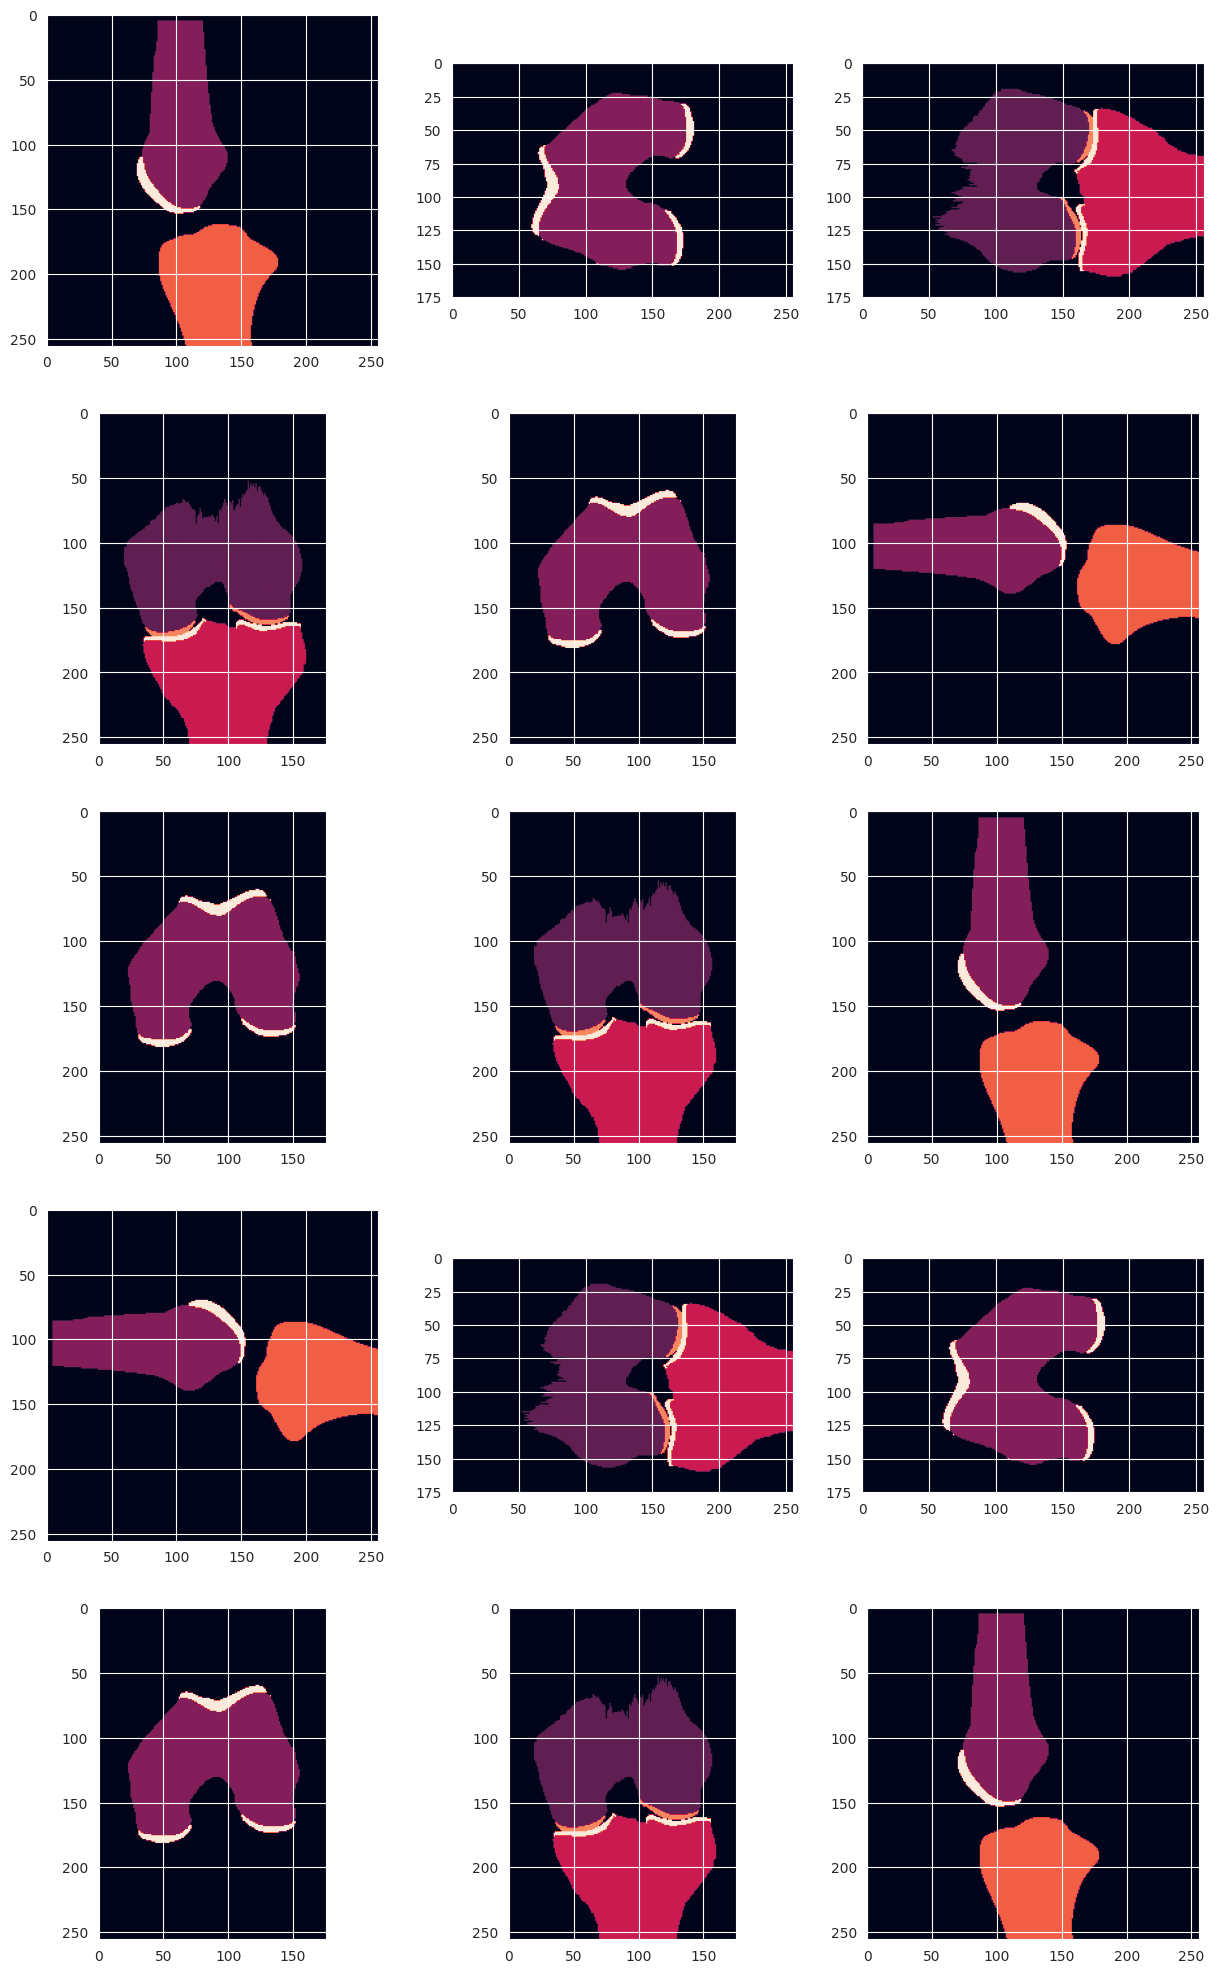

In [21]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(15, 25))
ax[0, 0].imshow(sitk.GetArrayFromImage(image)[90])
ax[0, 1].imshow(sitk.GetArrayFromImage(image)[:, 128])
ax[0, 2].imshow(sitk.GetArrayFromImage(image)[:, :, 128])
ax[1, 0].imshow(image_2.get_fdata()[128])
ax[1, 1].imshow(image_2.get_fdata()[:, 128])
ax[1, 2].imshow(image_2.get_fdata()[:, :, 90])
ax[2, 0].imshow(sitk.GetArrayFromImage(image_3)[128])
ax[2, 1].imshow(sitk.GetArrayFromImage(image_3)[:, 128])
ax[2, 2].imshow(sitk.GetArrayFromImage(image_3)[:, :, 90])
ax[3, 0].imshow(sitk.GetArrayFromImage(image_4)[90])
ax[3, 1].imshow(sitk.GetArrayFromImage(image_4)[:, 128])
ax[3, 2].imshow(sitk.GetArrayFromImage(image_4)[:, :, 128])
ax[4, 0].imshow(sitk.GetArrayFromImage(image_5)[128])
ax[4, 1].imshow(sitk.GetArrayFromImage(image_5)[:, 128])
ax[4, 2].imshow(sitk.GetArrayFromImage(image_5)[:, :, 90])
plt.show()

In [3]:
tibia = knee.Tibia(image, 4)

In [4]:
tibia.get_surface_points()

In [6]:
image.GetSpacing()

(0.625, 0.625, 0.6300007104873657)

In [7]:
image.GetSize()

(256, 256, 176)

In [6]:
tibia.calculate_thickness(method='knn')

{'clt': {(118.0, 138.0): 0.625,
  (118.0, 139.0): 1.3975424859373686,
  (118.0, 140.0): 1.7677669529663689,
  (118.0, 141.0): 2.2534695471649933,
  (118.0, 142.0): 2.651650429449553,
  (118.0, 143.0): 2.651650429449553,
  (118.0, 144.0): 2.2534695471649933,
  (118.0, 145.0): 1.9764235376052373,
  (118.0, 146.0): 1.875,
  (119.0, 137.0): 1.5309310892394863,
  (119.0, 138.0): 1.3975424859373686,
  (119.0, 139.0): 1.5309310892394863,
  (119.0, 140.0): 1.875,
  (119.0, 141.0): 2.3385358667337135,
  (119.0, 142.0): 2.576941016011038,
  (119.0, 143.0): 2.651650429449553,
  (119.0, 144.0): 2.3385358667337135,
  (119.0, 145.0): 2.0728904939721247,
  (119.0, 146.0): 1.7677669529663689,
  (119.0, 147.0): 1.3975424859373686,
  (119.0, 148.0): 0.625,
  (120.0, 136.0): 2.3385358667337135,
  (120.0, 137.0): 2.3385358667337135,
  (120.0, 138.0): 2.2534695471649933,
  (120.0, 139.0): 2.3385358667337135,
  (120.0, 140.0): 2.576941016011038,
  (120.0, 141.0): 2.8641098093474,
  (120.0, 142.0): 3.125,
  

In [7]:
p = pv.Plotter()
for subregion in ['clt', 'ilt', 'elt', 'alt', 'plt', 'crt', 'irt', 'ert', 'art', 'prt']:
    superior, inferior = knee.get_superior_and_inferior_surface_points(getattr(tibia, subregion))
    p.add_mesh(pv.PolyData(superior), color='red')
    p.add_mesh(pv.PolyData(inferior), color='blue')

p.show()

Widget(value='<iframe src="http://localhost:45209/index.html?ui=P_0x7508e3ef8ee0_1&reconnect=auto" class="pyvi…